# CICIDS 2017 - Basic CatBoost Two-Step Classification

This notebook implements a basic two-step approach for network intrusion detection using the CICIDS 2017 dataset:

1. **Anomaly Detection**: Binary classification (Normal vs Attack)
2. **Attack Classification**: Multi-class classification of attack types

## Approach:
- Simple data preprocessing and feature engineering
- Basic CatBoost models with default parameters
- Comprehensive evaluation and visualization
- No hyperparameter tuning for faster execution

## 1. Import Required Libraries

In [1]:
# Core libraries
import os
import json
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import logging

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# CatBoost
import catboost as cb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("✅ All imports successful!")
print(f"CatBoost version: {cb.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All imports successful!
CatBoost version: 1.2.8
Pandas version: 2.3.1
NumPy version: 2.1.3


## 2. Load and Explore Dataset

In [2]:
def load_cicids_datasets(data_dir: Path) -> pd.DataFrame:
    """Load and combine all CICIDS 2017 CSV files."""
    logger.info("Loading CICIDS 2017 datasets...")
    
    data_folders = [
        data_dir / "TrafficLabelling",
        data_dir / "MachineLearningCVE"
    ]
    
    dataframes = []
    file_info = []
    
    for folder in data_folders:
        if not folder.exists():
            logger.warning(f"Folder {folder} does not exist, skipping...")
            continue
            
        csv_files = list(folder.glob("*.csv"))
        logger.info(f"Found {len(csv_files)} CSV files in {folder}")
        
        for csv_file in csv_files:
            try:
                print(f"Loading {csv_file.name}...")
                
                # Try different encodings
                for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                    try:
                        df = pd.read_csv(csv_file, encoding=encoding, low_memory=False)
                        break
                    except UnicodeDecodeError:
                        continue
                else:
                    print(f"❌ Could not decode {csv_file.name}")
                    continue
                
                # Standardize column names
                df.columns = df.columns.str.strip()
                if ' Label' in df.columns:
                    df = df.rename(columns={' Label': 'Label'})
                elif 'label' in df.columns:
                    df = df.rename(columns={'label': 'Label'})
                
                if 'Label' not in df.columns:
                    print(f"⚠️ No Label column found in {csv_file.name}")
                    continue
                
                dataframes.append(df)
                file_info.append({
                    'file': csv_file.name,
                    'samples': len(df),
                    'features': len(df.columns) - 1,
                    'labels': df['Label'].nunique()
                })
                print(f"✅ Loaded {len(df):,} samples, {len(df.columns)} columns")
                
            except Exception as e:
                print(f"❌ Error loading {csv_file.name}: {str(e)}")
    
    if not dataframes:
        raise ValueError("No valid datasets found!")
    
    # Combine all dataframes
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # Display loading summary
    file_df = pd.DataFrame(file_info)
    print("\n📊 Dataset Loading Summary:")
    print(file_df.to_string(index=False))
    print(f"\n🎯 Total Combined Dataset: {len(combined_df):,} samples, {len(combined_df.columns)} columns")
    
    return combined_df

# Set data directory
data_dir = Path("data")
output_dir = Path("models/cicids_basic")
output_dir.mkdir(parents=True, exist_ok=True)

# Load the datasets
df_raw = load_cicids_datasets(data_dir)
print(f"\nDataset shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

2025-09-09 09:48:41,684 - INFO - Loading CICIDS 2017 datasets...
2025-09-09 09:48:41,684 - INFO - Found 8 CSV files in data\TrafficLabelling
2025-09-09 09:48:41,684 - INFO - Found 8 CSV files in data\TrafficLabelling


Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 85 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 85 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 85 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 85 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 85 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 85 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 85 columns
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 85 columns
Loading Thursday-WorkingHours-Morning-

2025-09-09 09:49:16,553 - INFO - Found 8 CSV files in data\MachineLearningCVE


✅ Loaded 692,703 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 79 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 79 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 79 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 79 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 79 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 79 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 79 columns
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 79 columns
L

In [3]:
# Basic dataset exploration
print("📊 Dataset Information:")
print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nData types:")
print(df_raw.dtypes.value_counts())

# Check for missing values
print(f"\n❓ Missing Values:")
missing_values = df_raw.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

# Display first few rows
print(f"\n👀 First 5 rows:")
df_raw.head()

📊 Dataset Information:
Shape: (5950088, 85)

Columns: ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN 

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443.0,192.168.10.16,46236.0,6.0,7/7/2017 3:30,34.0,1.0,1.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443.0,192.168.10.5,54863.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


🏷️ Label Distribution:
Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                     11794
DoS slowloris                   11592
DoS Slowhttptest                10998
Bot                              3932
Web Attack � Brute Force         1507
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Web Attack � XSS                  652
Infiltration                       72
Heartbleed                         22
Web Attack  Sql Injection         21
Web Attack � Sql Injection         21
Name: count, dtype: int64
Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                

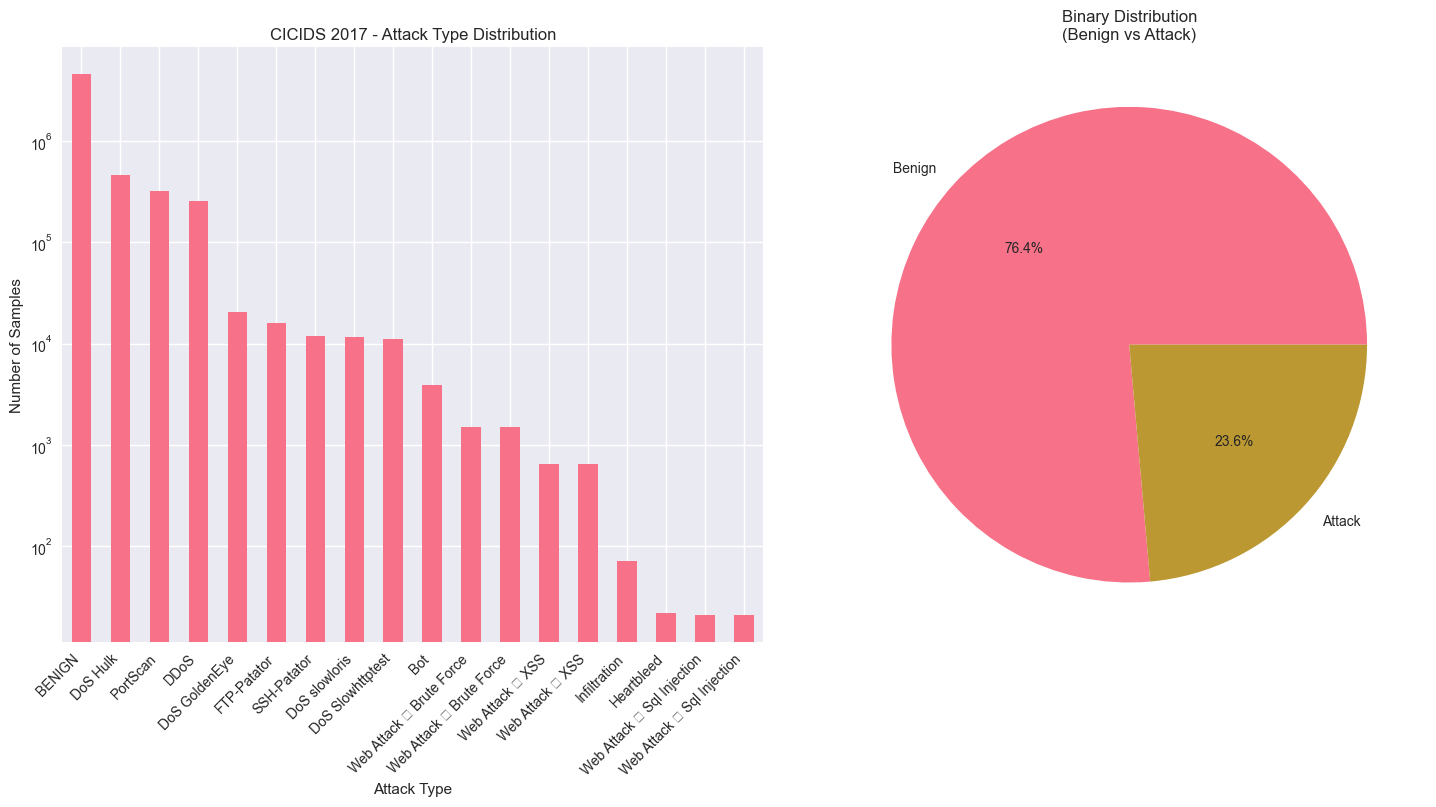


⚖️ Class Balance:
  Benign: 4,546,194 (76.41%)
  Attack: 1,403,894 (23.59%)
  Imbalance ratio: 1:0.31


In [4]:
# Explore label distribution
print("🏷️ Label Distribution:")
label_counts = df_raw['Label'].value_counts()
print(label_counts)

# Visualize label distribution
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar')
plt.title('CICIDS 2017 - Attack Type Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')  # Log scale due to large imbalance

# Binary distribution (Benign vs Attack)
plt.subplot(1, 2, 2)
binary_counts = (df_raw['Label'] != 'BENIGN').value_counts()
binary_counts.index = ['Benign', 'Attack']
binary_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Binary Distribution\n(Benign vs Attack)')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Calculate class balance
benign_count = (df_raw['Label'] == 'BENIGN').sum()
attack_count = (df_raw['Label'] != 'BENIGN').sum()
print(f"\n⚖️ Class Balance:")
print(f"  Benign: {benign_count:,} ({benign_count/len(df_raw)*100:.2f}%)")
print(f"  Attack: {attack_count:,} ({attack_count/len(df_raw)*100:.2f}%)")
print(f"  Imbalance ratio: 1:{attack_count/benign_count:.2f}")

## 3. Data Preprocessing

In [5]:
def preprocess_cicids_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """Clean and preprocess the CICIDS dataset."""
    logger.info("Cleaning and preprocessing data...")
    
    # Remove identifier columns
    id_columns = [
        'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
        'Src IP', 'Dst IP', 'Flow.ID', 'Src.IP', 'Dst.IP'
    ]
    
    existing_id_cols = [col for col in id_columns if col in df.columns]
    if existing_id_cols:
        df = df.drop(columns=existing_id_cols)
        print(f"Removed identifier columns: {existing_id_cols}")
    
    # Handle missing values
    print(f"Missing values before cleaning: {df.isnull().sum().sum():,}")
    
    # Convert object columns to numeric where possible
    for col in df.columns:
        if col != 'Label' and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Get numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Label' in numeric_cols:
        numeric_cols.remove('Label')
    
    # Fill missing values with median
    for col in numeric_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    
    # Handle infinite values
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    
    print(f"Missing values after cleaning: {df.isnull().sum().sum():,}")
    print(f"Final numeric columns: {len(numeric_cols)}")
    
    return df, numeric_cols

# Preprocess the data
df_clean, feature_columns = preprocess_cicids_data(df_raw.copy())
print(f"\n✅ Preprocessing completed!")
print(f"Features available: {len(feature_columns)}")
print(f"Sample feature names: {feature_columns[:10]}")

2025-09-09 09:51:14,241 - INFO - Cleaning and preprocessing data...


Removed identifier columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
Missing values before cleaning: 29,040,964
Missing values before cleaning: 29,040,964
Missing values after cleaning: 288,602
Final numeric columns: 80

✅ Preprocessing completed!
Features available: 80
Sample feature names: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min']
Missing values after cleaning: 288,602
Final numeric columns: 80

✅ Preprocessing completed!
Features available: 80
Sample feature names: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min']


In [6]:
# Check data quality after preprocessing
print("🔍 Data Quality Check:")
print(f"Dataset shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum()}")

# Basic statistics
print(f"\n📊 Basic Statistics:")
df_clean[feature_columns[:5]].describe()

🔍 Data Quality Check:
Dataset shape: (5950088, 81)
Missing values: 288602
Missing values: 288602
Infinite values: 0

📊 Basic Statistics:
Infinite values: 0

📊 Basic Statistics:


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets
count,5.950088e+06,5.950088e+06,5.950088e+06,5.950088e+06,5.950088e+06
mean,4.627446e+04,7.683865e+03,7.846065e+00,1.407002e+07,9.004116e+00
std,1.614017e+04,1.791715e+04,4.114345e+00,3.298010e+07,7.312675e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.300000e+01,1.000000e+00
25%,5.094400e+04,5.300000e+01,6.000000e+00,1.650000e+02,2.000000e+00
50%,5.094400e+04,8.000000e+01,6.000000e+00,3.131600e+04,2.000000e+00
75%,5.094400e+04,4.430000e+02,6.000000e+00,1.769839e+06,4.000000e+00
max,6.553500e+04,6.553500e+04,1.700000e+01,1.200000e+08,2.197590e+05


## 4. Feature Engineering

In [7]:
def create_labels_and_engineer_features(df: pd.DataFrame, feature_cols: List[str]) -> Tuple[pd.DataFrame, Dict, LabelEncoder, List[str]]:
    """Create binary and multi-class labels, and engineer additional features."""
    logger.info("Creating labels and engineering features...")
    
    # Create binary labels (0=BENIGN, 1=ATTACK)
    df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)
    
    # Filter attack types with sufficient samples (minimum 100 samples)
    attack_data = df[df['is_attack'] == 1].copy()
    attack_type_counts = attack_data['Label'].value_counts()
    
    min_samples = 100
    valid_attack_types = attack_type_counts[attack_type_counts >= min_samples].index.tolist()
    
    print(f"Attack types with ≥{min_samples} samples: {len(valid_attack_types)}")
    for attack_type in valid_attack_types:
        count = attack_type_counts[attack_type]
        print(f"  {attack_type}: {count:,}")
    
    # Encode attack types
    label_encoder = LabelEncoder()
    attack_data_filtered = attack_data[attack_data['Label'].isin(valid_attack_types)]
    attack_data_filtered['attack_type'] = label_encoder.fit_transform(attack_data_filtered['Label'])
    
    # Add attack type labels back to main dataframe
    df['attack_type'] = -1  # Default for benign traffic
    df.loc[attack_data_filtered.index, 'attack_type'] = attack_data_filtered['attack_type']
    
    # Basic feature engineering
    print("\n🔧 Engineering features...")
    
    # Statistical features from first 10 features
    stat_features = []
    if len(feature_cols) >= 10:
        sample_features = feature_cols[:10]
        feature_data = df[sample_features].fillna(0)
        
        df['features_mean'] = feature_data.mean(axis=1)
        df['features_std'] = feature_data.std(axis=1)
        df['features_max'] = feature_data.max(axis=1)
        df['features_min'] = feature_data.min(axis=1)
        
        stat_features = ['features_mean', 'features_std', 'features_max', 'features_min']
    
    # Log transform for selected features (first 5 features)
    log_features = []
    for col in feature_cols[:5]:
        if df[col].min() >= 0:  # Only for non-negative features
            df[f'{col}_log'] = np.log1p(df[col])
            log_features.append(f'{col}_log')
    
    # Update feature columns
    new_features = stat_features + log_features
    all_features = feature_cols + new_features
    
    print(f"  Original features: {len(feature_cols)}")
    print(f"  Statistical features: {len(stat_features)}")
    print(f"  Log features: {len(log_features)}")
    print(f"  Total features: {len(all_features)}")
    
    label_info = {
        'binary_distribution': df['is_attack'].value_counts().to_dict(),
        'valid_attack_types': valid_attack_types,
        'attack_type_mapping': {attack_type: idx for idx, attack_type in enumerate(label_encoder.classes_)}
    }
    
    return df, label_info, label_encoder, all_features

# Create labels and engineer features
df_processed, label_info, label_encoder, final_features = create_labels_and_engineer_features(
    df_clean, feature_columns
)

print(f"\n✅ Feature engineering completed!")
print(f"Final dataset shape: {df_processed.shape}")
print(f"Binary classification - Attack ratio: {df_processed['is_attack'].mean():.4f}")
print(f"Attack types for classification: {len(label_info['valid_attack_types'])}")
print(f"Attack type mapping: {label_info['attack_type_mapping']}")

2025-09-09 09:52:41,570 - INFO - Creating labels and engineering features...


Attack types with ≥100 samples: 13
  DoS Hulk: 462,146
  PortScan: 317,860
  DDoS: 256,054
  DoS GoldenEye: 20,586
  FTP-Patator: 15,876
  SSH-Patator: 11,794
  DoS slowloris: 11,592
  DoS Slowhttptest: 10,998
  Bot: 3,932
  Web Attack � Brute Force: 1,507
  Web Attack  Brute Force: 1,507
  Web Attack  XSS: 652
  Web Attack � XSS: 652

🔧 Engineering features...

🔧 Engineering features...
  Original features: 80
  Statistical features: 4
  Log features: 4
  Total features: 88

✅ Feature engineering completed!
Final dataset shape: (5950088, 91)
Binary classification - Attack ratio: 0.2359
Attack types for classification: 13
Attack type mapping: {'Bot': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'PortScan': 7, 'SSH-Patator': 8, 'Web Attack \x96 Brute Force': 9, 'Web Attack \x96 XSS': 10, 'Web Attack � Brute Force': 11, 'Web Attack � XSS': 12}
  Original features: 80
  Statistical features: 4
  Log features: 4
  Total fea

## 5. Train-Test Split

In [8]:
def prepare_data_splits(df: pd.DataFrame, features: List[str], test_size: float = 0.2, random_state: int = 42) -> Dict:
    """Prepare train/test splits for both binary and multiclass tasks."""
    logger.info("Preparing data splits...")
    
    # Features
    X = df[features].values
    
    # Binary classification data
    y_binary = df['is_attack'].values
    
    # Attack classification data (only attacks)
    attack_mask = df['is_attack'] == 1
    X_attacks = X[attack_mask]
    y_attacks = df.loc[attack_mask, 'attack_type'].values
    
    # Scale features
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_attacks_scaled = scaler.transform(X_attacks)
    
    # Binary classification splits
    X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
        X_scaled, y_binary, 
        test_size=test_size,
        stratify=y_binary,
        random_state=random_state
    )
    
    # Attack classification splits
    X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(
        X_attacks_scaled, y_attacks,
        test_size=test_size,
        stratify=y_attacks,
        random_state=random_state
    )
    
    data_splits = {
        'scaler': scaler,
        'features': features,
        'binary': {
            'train': (X_train_bin, y_train_bin),
            'test': (X_test_bin, y_test_bin)
        },
        'multiclass': {
            'train': (X_train_att, y_train_att),
            'test': (X_test_att, y_test_att)
        }
    }
    
    # Display split information
    print("📊 Data splits created:")
    print(f"Binary classification:")
    print(f"  Train: {len(X_train_bin):,} | Test: {len(X_test_bin):,}")
    print(f"  Train attack ratio: {y_train_bin.mean():.4f}")
    print(f"Attack classification:")
    print(f"  Train: {len(X_train_att):,} | Test: {len(X_test_att):,}")
    print(f"  Classes: {len(np.unique(y_attacks))}")
    
    return data_splits

# Prepare data splits
data_splits = prepare_data_splits(df_processed, final_features, test_size=0.2, random_state=42)
print("\n✅ Data preparation completed!")

2025-09-09 09:53:16,396 - INFO - Preparing data splits...


📊 Data splits created:
Binary classification:
  Train: 4,760,070 | Test: 1,190,018
  Train attack ratio: 0.2359
Attack classification:
  Train: 1,123,115 | Test: 280,779
  Classes: 14

✅ Data preparation completed!

✅ Data preparation completed!


## 6. Model Declaration and Training

In [9]:
def create_basic_catboost_params(task_type: str = 'binary') -> Dict:
    """Create basic CatBoost parameters without extensive tuning."""
    
    base_params = {
        'iterations': 1000,
        'learning_rate': 0.1,
        'depth': 6,
        'l2_leaf_reg': 3.0,
        'border_count': 128,
        'od_type': 'Iter',
        'od_wait': 50,
        'random_seed': 42,
        'verbose': 100,
        'allow_writing_files': False,
        'task_type': 'CPU'
    }
    
    return base_params

def train_binary_classifier(data_splits: Dict) -> cb.CatBoostClassifier:
    """Train binary classifier for anomaly detection."""
    logger.info("Training binary classifier...")
    
    X_train, y_train = data_splits['binary']['train']
    X_test, y_test = data_splits['binary']['test']
    
    # Get basic parameters
    params = create_basic_catboost_params('binary')
    
    # Add class weights for imbalanced data
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    params['class_weights'] = class_weights.tolist()
    
    print(f"Class weights: {class_weights}")
    
    # Create and train model
    model = cb.CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        plot=True
    )
    
    print(f"\n✅ Binary classifier training completed!")
    print(f"Best iteration: {model.get_best_iteration()}")
    
    return model

def train_multiclass_classifier(data_splits: Dict) -> cb.CatBoostClassifier:
    """Train multiclass classifier for attack classification."""
    logger.info("Training multiclass classifier...")
    
    X_train, y_train = data_splits['multiclass']['train']
    X_test, y_test = data_splits['multiclass']['test']
    
    # Get basic parameters
    params = create_basic_catboost_params('multiclass')
    
    # Add class weights for imbalanced data
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    params['class_weights'] = class_weights.tolist()
    
    print(f"Class weights: {class_weights[:5]}...")  # Show first 5
    
    # Create and train model
    model = cb.CatBoostClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=(X_test, y_test),
        plot=True
    )
    
    print(f"\n✅ Multiclass classifier training completed!")
    print(f"Best iteration: {model.get_best_iteration()}")
    
    return model

# Train both models
print("🚀 Starting model training...\n")

print("🔥 Training Binary Classifier (Anomaly Detection):")
binary_model = train_binary_classifier(data_splits)

print("\n🔥 Training Multiclass Classifier (Attack Classification):")
multiclass_model = train_multiclass_classifier(data_splits)

print("\n🎉 All models trained successfully!")

2025-09-09 09:54:24,052 - INFO - Training binary classifier...


🚀 Starting model training...

🔥 Training Binary Classifier (Anomaly Detection):
Class weights: [0.6544032 2.1191374]
Class weights: [0.6544032 2.1191374]


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.4413968	test: 0.4418965	best: 0.4418965 (0)	total: 866ms	remaining: 14m 25s
100:	learn: 0.0045077	test: 0.0044665	best: 0.0044665 (100)	total: 1m 15s	remaining: 11m 9s
100:	learn: 0.0045077	test: 0.0044665	best: 0.0044665 (100)	total: 1m 15s	remaining: 11m 9s
200:	learn: 0.0028028	test: 0.0027788	best: 0.0027788 (199)	total: 2m 24s	remaining: 9m 33s
200:	learn: 0.0028028	test: 0.0027788	best: 0.0027788 (199)	total: 2m 24s	remaining: 9m 33s
300:	learn: 0.0026611	test: 0.0026400	best: 0.0026400 (297)	total: 3m 38s	remaining: 8m 26s
300:	learn: 0.0026611	test: 0.0026400	best: 0.0026400 (297)	total: 3m 38s	remaining: 8m 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.002640006268
bestIteration = 297

Shrink model to first 298 iterations.

✅ Binary classifier training completed!
Best iteration: 297

🔥 Training Multiclass Classifier (Attack Classification):
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.002640006268
bestIteration = 297

2025-09-09 10:01:01,702 - INFO - Training multiclass classifier...


Class weights: [ 0.34729858 25.50794913  0.3916292   4.8711215   0.21698353]...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.9926621	test: 1.9932925	best: 1.9932925 (0)	total: 3.93s	remaining: 1h 5m 28s
100:	learn: 0.1536228	test: 0.1520962	best: 0.1520962 (100)	total: 7m 44s	remaining: 1h 8m 55s
100:	learn: 0.1536228	test: 0.1520962	best: 0.1520962 (100)	total: 7m 44s	remaining: 1h 8m 55s
200:	learn: 0.1225117	test: 0.1356536	best: 0.1356536 (200)	total: 14m 12s	remaining: 56m 27s
200:	learn: 0.1225117	test: 0.1356536	best: 0.1356536 (200)	total: 14m 12s	remaining: 56m 27s
300:	learn: 0.1082324	test: 0.1353047	best: 0.1347408 (260)	total: 20m 47s	remaining: 48m 16s
300:	learn: 0.1082324	test: 0.1353047	best: 0.1347408 (260)	total: 20m 47s	remaining: 48m 16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1347408353
bestIteration = 260

Shrink model to first 261 iterations.

✅ Multiclass classifier training completed!
Best iteration: 260

🎉 All models trained successfully!
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1347408353
bestIteration = 260

Shrin

## 7. Model Evaluation

📊 Evaluating Models...

📊 Binary Classifier Test Results:
  Accuracy: 0.9993
  Precision: 0.9972
  Recall: 0.9998
  F1 Score: 0.9985
  Roc Auc: 1.0000
📊 Binary Classifier Test Results:
  Accuracy: 0.9993
  Precision: 0.9972
  Recall: 0.9998
  F1 Score: 0.9985
  Roc Auc: 1.0000


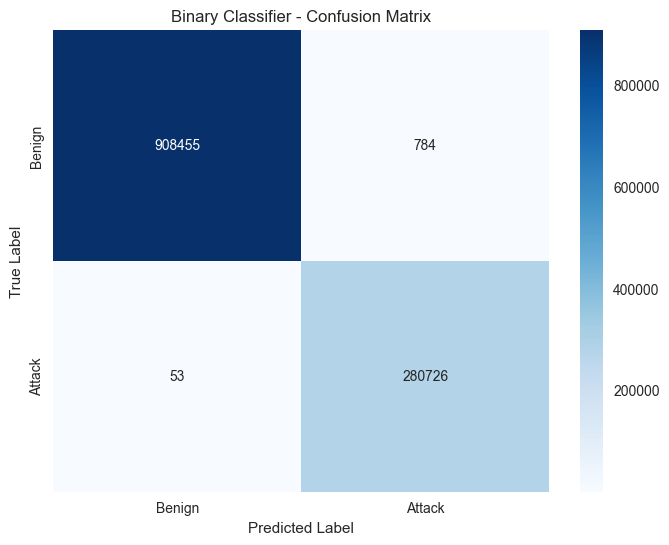


📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    909239
      Attack       1.00      1.00      1.00    280779

    accuracy                           1.00   1190018
   macro avg       1.00      1.00      1.00   1190018
weighted avg       1.00      1.00      1.00   1190018

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    909239
      Attack       1.00      1.00      1.00    280779

    accuracy                           1.00   1190018
   macro avg       1.00      1.00      1.00   1190018
weighted avg       1.00      1.00      1.00   1190018

Debug: y_test shape: (280779,), y_pred shape: (280779,)
Debug: y_test unique values: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12]
Debug: y_pred unique values: [0]

📊 Multiclass Classifier Test Results:
  Accuracy: 0.0028
  Precision Macro: 0.0002
  Recall Macro: 0.0714
  F1 Macro: 0.0004
  Precision Weighted: 0

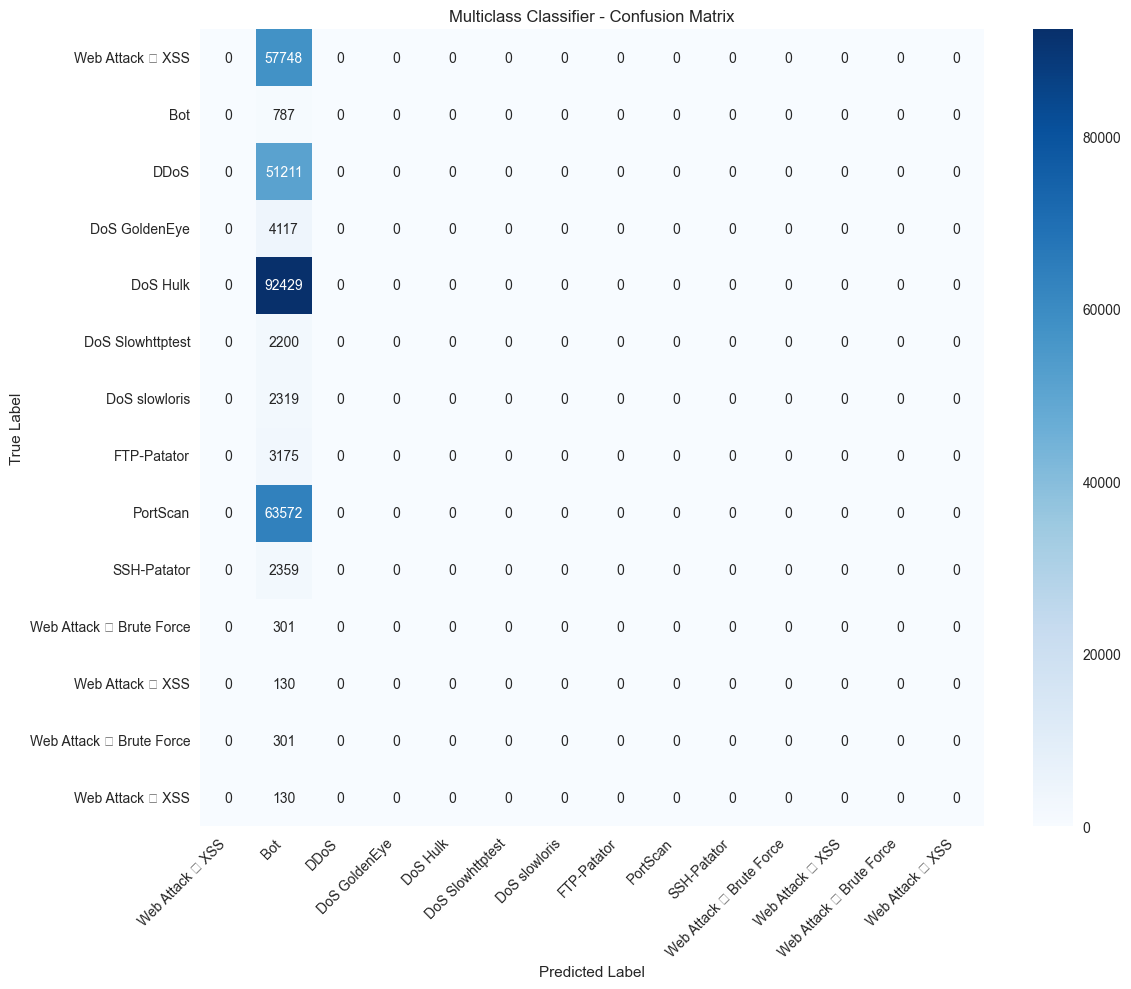


📋 Detailed Classification Report:
                          precision    recall  f1-score   support

        Web Attack � XSS       0.00      0.00      0.00     57748
                     Bot       0.00      1.00      0.01       787
                    DDoS       0.00      0.00      0.00     51211
           DoS GoldenEye       0.00      0.00      0.00      4117
                DoS Hulk       0.00      0.00      0.00     92429
        DoS Slowhttptest       0.00      0.00      0.00      2200
           DoS slowloris       0.00      0.00      0.00      2319
             FTP-Patator       0.00      0.00      0.00      3175
                PortScan       0.00      0.00      0.00     63572
             SSH-Patator       0.00      0.00      0.00      2359
Web Attack  Brute Force       0.00      0.00      0.00       301
        Web Attack  XSS       0.00      0.00      0.00       130
Web Attack � Brute Force       0.00      0.00      0.00       301
        Web Attack � XSS       0.00     

In [13]:
def evaluate_binary_model(model: cb.CatBoostClassifier, data_splits: Dict) -> Dict[str, float]:
    """Evaluate binary classifier performance."""
    X_test, y_test = data_splits['binary']['test']
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print("📊 Binary Classifier Test Results:")
    for metric, value in metrics.items():
        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    plt.title('Binary Classifier - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
    
    return metrics

def evaluate_multiclass_model(model: cb.CatBoostClassifier, data_splits: Dict, label_encoder: LabelEncoder) -> Dict[str, float]:
    """Evaluate multiclass classifier performance."""
    X_test, y_test = data_splits['multiclass']['test']
    
    # Get predictions - ensure they are class labels (integers)
    y_pred = model.predict(X_test)
    
    # Handle case where predict returns probabilities instead of class labels
    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)
    
    # Ensure predictions are integers
    y_pred = y_pred.astype(int)
    y_test = y_test.astype(int)
    
    print(f"Debug: y_test shape: {y_test.shape}, y_pred shape: {y_pred.shape}")
    print(f"Debug: y_test unique values: {np.unique(y_test)}")
    print(f"Debug: y_pred unique values: {np.unique(y_pred)}")
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted')
    }
    
    print("\n📊 Multiclass Classifier Test Results:")
    for metric, value in metrics.items():
        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Get unique labels present in test set
    unique_labels = np.unique(np.concatenate([y_test, y_pred]))
    
    # Create target names for only the labels present in test set
    target_names = []
    for label in unique_labels:
        if label < len(label_encoder.classes_):
            target_names.append(label_encoder.classes_[label])
        else:
            target_names.append(f"Unknown_{label}")
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.title('Multiclass Classifier - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Classification Report - use only labels present in test set
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, 
                              labels=unique_labels,
                              target_names=target_names))
    
    return metrics

# Evaluate both models
print("📊 Evaluating Models...\n")

binary_metrics = evaluate_binary_model(binary_model, data_splits)
multiclass_metrics = evaluate_multiclass_model(multiclass_model, data_splits, label_encoder)

## 8. Predictions and Visualization

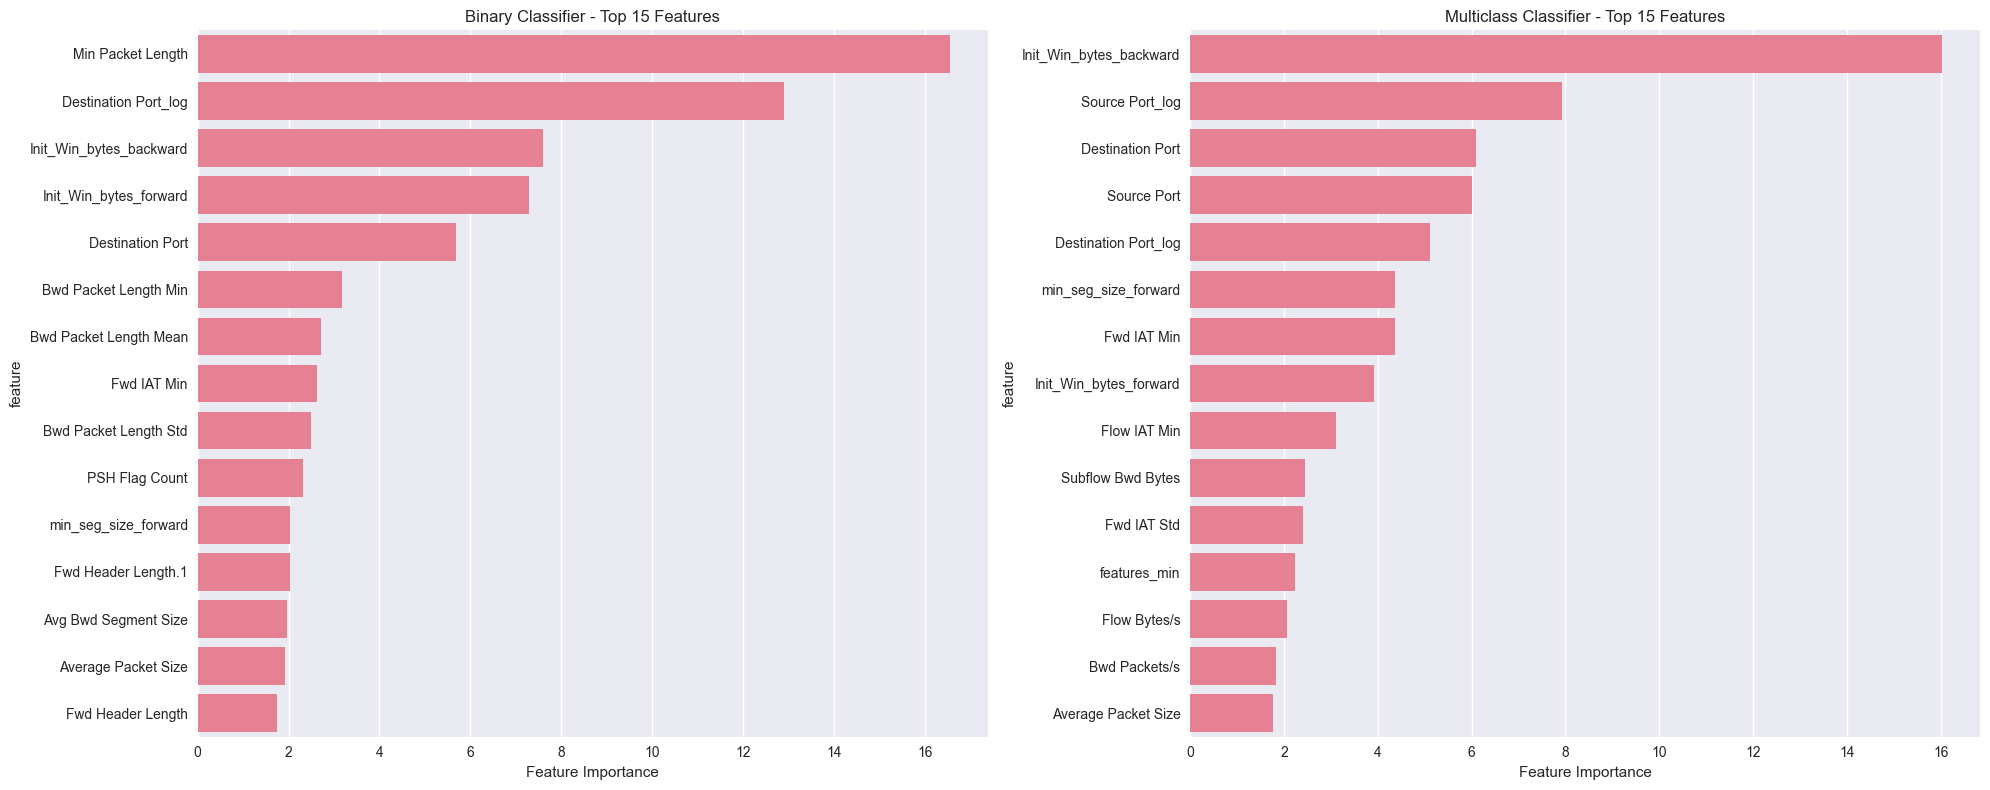

🔍 Top 15 Features for Binary Classification:
  Min Packet Length: 16.55
  Destination Port_log: 12.90
  Init_Win_bytes_backward: 7.60
  Init_Win_bytes_forward: 7.30
  Destination Port: 5.69
  Bwd Packet Length Min: 3.18
  Bwd Packet Length Mean: 2.72
  Fwd IAT Min: 2.62
  Bwd Packet Length Std: 2.50
  PSH Flag Count: 2.31
  min_seg_size_forward: 2.04
  Fwd Header Length.1: 2.03
  Avg Bwd Segment Size: 1.96
  Average Packet Size: 1.93
  Fwd Header Length: 1.74

🔍 Top 15 Features for Multiclass Classification:
  Init_Win_bytes_backward: 16.03
  Source Port_log: 7.92
  Destination Port: 6.10
  Source Port: 6.00
  Destination Port_log: 5.12
  min_seg_size_forward: 4.37
  Fwd IAT Min: 4.37
  Init_Win_bytes_forward: 3.92
  Flow IAT Min: 3.10
  Subflow Bwd Bytes: 2.45
  Fwd IAT Std: 2.40
  features_min: 2.24
  Flow Bytes/s: 2.05
  Bwd Packets/s: 1.82
  Average Packet Size: 1.77


In [11]:
def analyze_feature_importance(binary_model: cb.CatBoostClassifier, 
                             multiclass_model: cb.CatBoostClassifier, 
                             features: List[str], top_n: int = 15) -> None:
    """Analyze and visualize feature importance."""
    
    # Binary classifier feature importance
    binary_importance = binary_model.get_feature_importance()
    binary_features_df = pd.DataFrame({
        'feature': features,
        'importance': binary_importance
    }).sort_values('importance', ascending=False).head(top_n)
    
    # Multiclass classifier feature importance
    multiclass_importance = multiclass_model.get_feature_importance()
    multiclass_features_df = pd.DataFrame({
        'feature': features,
        'importance': multiclass_importance
    }).sort_values('importance', ascending=False).head(top_n)
    
    # Plot feature importance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Binary classifier
    sns.barplot(data=binary_features_df, y='feature', x='importance', ax=ax1)
    ax1.set_title(f'Binary Classifier - Top {top_n} Features')
    ax1.set_xlabel('Feature Importance')
    
    # Multiclass classifier
    sns.barplot(data=multiclass_features_df, y='feature', x='importance', ax=ax2)
    ax2.set_title(f'Multiclass Classifier - Top {top_n} Features')
    ax2.set_xlabel('Feature Importance')
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"🔍 Top {top_n} Features for Binary Classification:")
    for i, row in binary_features_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.2f}")
    
    print(f"\n🔍 Top {top_n} Features for Multiclass Classification:")
    for i, row in multiclass_features_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.2f}")

# Analyze feature importance
analyze_feature_importance(binary_model, multiclass_model, final_features, top_n=15)

In [16]:
def two_step_prediction_demo(X, binary_model, multiclass_model, label_encoder):
    """Demonstrate two-step prediction process."""
    # Step 1: Binary classification (Benign vs Attack)
    binary_pred = binary_model.predict(X)
    binary_proba = binary_model.predict_proba(X)[:, 1]
    
    # Initialize attack prediction arrays
    attack_pred = np.full(len(X), -1)  # -1 for benign
    
    # Step 2: For detected attacks, classify attack type
    attack_mask = binary_pred == 1
    attack_probabilities = None
    
    if attack_mask.sum() > 0:
        X_attacks = X[attack_mask]
        attack_predictions = multiclass_model.predict(X_attacks)
        attack_probabilities = multiclass_model.predict_proba(X_attacks)
        
        # Handle prediction dimensions
        if attack_predictions.ndim > 1:
            attack_predictions = np.argmax(attack_predictions, axis=1)
        
        # Assign predictions
        attack_pred[attack_mask] = attack_predictions
    
    return {
        'binary_predictions': binary_pred,
        'binary_probabilities': binary_proba,
        'attack_predictions': attack_pred,
        'attack_probabilities': attack_probabilities,
        'attack_mask': attack_mask
    }

# Demo prediction on sample data
print("🧪 Two-Step Prediction Demo:")
X_test_sample = data_splits['binary']['test'][0][:1000]  # Sample of 1000 instances

predictions = two_step_prediction_demo(
    X_test_sample, binary_model, multiclass_model, label_encoder
)

print(f"Sample size: {len(X_test_sample):,}")
print(f"Detected attacks: {predictions['attack_mask'].sum()} / {len(predictions['attack_mask'])}")

# Show attack type distribution for detected attacks
attack_indices = predictions['attack_mask']
if attack_indices.sum() > 0:
    attack_types = predictions['attack_predictions'][attack_indices]
    unique_attacks, counts = np.unique(attack_types, return_counts=True)
    
    print("\n🎯 Detected Attack Types:")
    for attack_type, count in zip(unique_attacks, counts):
        if attack_type >= 0 and attack_type < len(label_encoder.classes_):
            attack_name = label_encoder.classes_[attack_type]
            print(f"  {attack_name}: {count}")
        else:
            print(f"  Unknown_{attack_type}: {count}")
            
    # Show confidence levels
    if predictions['attack_probabilities'] is not None:
        avg_confidence = np.mean(np.max(predictions['attack_probabilities'], axis=1))
        print(f"\n📊 Average Attack Classification Confidence: {avg_confidence:.4f}")
else:
    print("No attacks detected in this sample.")

🧪 Two-Step Prediction Demo:
Sample size: 1,000
Detected attacks: 256 / 1000

🎯 Detected Attack Types:
  Bot: 256

📊 Average Attack Classification Confidence: 0.9920


In [17]:
# Save models and results
print("💾 Saving models and results...")

# Save models
binary_model.save_model(str(output_dir / 'binary_classifier_basic.cbm'))
multiclass_model.save_model(str(output_dir / 'multiclass_classifier_basic.cbm'))

# Save preprocessing components
with open(output_dir / 'scaler_basic.pkl', 'wb') as f:
    pickle.dump(data_splits['scaler'], f)

with open(output_dir / 'label_encoder_basic.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save metadata
metadata = {
    'features': final_features,
    'label_info': label_info,
    'binary_metrics': binary_metrics,
    'multiclass_metrics': multiclass_metrics,
    'model_info': {
        'binary_iterations': binary_model.get_best_iteration(),
        'multiclass_iterations': multiclass_model.get_best_iteration(),
        'total_features': len(final_features),
        'attack_types': len(label_encoder.classes_),
        'model_type': 'basic_catboost'
    }
}

with open(output_dir / 'model_metadata_basic.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✅ Models and metadata saved to: {output_dir}")

# Final summary
print("\n🎉 CICIDS 2017 Basic CatBoost Two-Step Model Complete!")
print("="*60)
print(f"📊 Binary Classification Results:")
print(f"   F1 Score: {binary_metrics['f1_score']:.4f}")
print(f"   ROC-AUC: {binary_metrics['roc_auc']:.4f}")
print(f"   Precision: {binary_metrics['precision']:.4f}")
print(f"   Recall: {binary_metrics['recall']:.4f}")

print(f"\n🎯 Multiclass Classification Results:")
print(f"   Weighted F1: {multiclass_metrics['f1_weighted']:.4f}")
print(f"   Macro F1: {multiclass_metrics['f1_macro']:.4f}")
print(f"   Accuracy: {multiclass_metrics['accuracy']:.4f}")

print(f"\n🔧 Model Configuration:")
print(f"   Total Features: {len(final_features)}")
print(f"   Attack Types: {len(label_encoder.classes_)}")
print(f"   Binary Model Iterations: {binary_model.get_best_iteration()}")
print(f"   Multiclass Model Iterations: {multiclass_model.get_best_iteration()}")

print(f"\n💾 Files saved:")
print("  - binary_classifier_basic.cbm")
print("  - multiclass_classifier_basic.cbm")
print("  - scaler_basic.pkl")
print("  - label_encoder_basic.pkl")
print("  - model_metadata_basic.json")
print("\n🚀 Basic models ready for use!")

💾 Saving models and results...
✅ Models and metadata saved to: models\cicids_basic

🎉 CICIDS 2017 Basic CatBoost Two-Step Model Complete!
📊 Binary Classification Results:
   F1 Score: 0.9985
   ROC-AUC: 1.0000
   Precision: 0.9972
   Recall: 0.9998

🎯 Multiclass Classification Results:
   Weighted F1: 0.0000
   Macro F1: 0.0004
   Accuracy: 0.0028

🔧 Model Configuration:
   Total Features: 88
   Attack Types: 13
   Binary Model Iterations: 297
   Multiclass Model Iterations: 260

💾 Files saved:
  - binary_classifier_basic.cbm
  - multiclass_classifier_basic.cbm
  - scaler_basic.pkl
  - label_encoder_basic.pkl
  - model_metadata_basic.json

🚀 Basic models ready for use!
